# 03. Airfoil validation analysis and next experiments

**Purpose:** identify what the completed 10,000-step ablations establish, then prepare fair comparisons with DFP, U-Net, FNO, and an optional conventional CNN refinement control.

The observed refinement-branch gains are **1.89% in scaled L1, 8.29% in pressure relative L2, and 8.14% in velocity relative L2**. They occur in every observed seed. Alignment and adaptive weighting have small or mixed effects.

**Start here:** upload this notebook to Colab, use a standard CPU runtime, and run the analysis cells through **Stage 2**. The existing project path is already entered. All helper code is embedded. It uses your existing `airfoil_publication_core.py` only for optional GPU work and experiment configuration. A GPU is unnecessary for the initial CSV analysis.

**Saved-output status:** the displayed seed tables and seed-effect figure were executed from the exact 12 attached result rows. They are a snapshot. The live Drive audit, case-level intervals, CFD figures, inference measurements, and new training require your saved project and have not been executed here. `MODE` defaults to `drive` when you rerun the notebook. No new measured results are fabricated.

| Stage | Work | GPU | Training |
|---|---|---|---|
| 1 | Verify completed runs, case identities, selected losses, and experiment settings | No | None |
| 2 | Paired regional analysis, seed effects, hard-case selection | No | None |
| 3 | Matched validation fields and inference timing | Yes | None |
| 4 | Prepare the fixed next-experiment plan | No | None |
| 5 | One resumable chunk for one selected new experiment | Yes | Optional |
| 6 | Compare completed new experiments with the existing ablations | No | None |

The existing study is an input. New experiment records use `runs/study_04/matched_validation_10k_3seeds`. This notebook contains no official test-set evaluation.


## Stage 1. Connect and audit

Keep the seeds, total budget, validation interval, optimizer settings, and existing split fixed. Start with the three GPU options disabled. To inspect only the embedded result snapshot away from Colab, use `MODE = "snapshot"`.


In [1]:
import os
import sys
import io
import json
import hashlib
import importlib.util
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, "to_string") else value)

MODE = os.environ.get("AIRFOIL_NEXT_MODE", "drive")  # "drive" or "snapshot"
PROJECT_ROOT = Path(os.environ.get("AIRFOIL_PROJECT_ROOT",
    "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2"))
PREPARED_ROOT = PROJECT_ROOT / "prepared"
SPLIT_PATH = PREPARED_ROOT / "splits" / "official_random_31415.json"
STUDY_ROOT = PROJECT_ROOT / "runs" / "study_03" / "ablations_10k_3seeds"
NEXT_ROOT = PROJECT_ROOT / "runs" / "study_04" / "matched_validation_10k_3seeds"
CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"

RUN_VALIDATION_FIGURES = False
RUN_INFERENCE_TIMING = False
RUN_NEXT_CHUNK = False
ACTIVE_EXPERIMENTS = ["dfp_original", "modern_unet", "fno"]
# Later, use ["conv_refiner_control"] to run the optional mechanism control.
CHUNK_STEPS = 500  # Start with one checkpoint interval; increase to 1_000 after a successful resume.
SESSION_MINUTES = 8  # Soft limit, checked at saved 500-step boundaries.
BOOTSTRAP_REPETITIONS = 4_000

if MODE not in {"drive", "snapshot"}:
    raise ValueError("MODE must be drive or snapshot.")
if MODE == "drive":
    if "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG"):
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    for required in [PREPARED_ROOT / "metadata.json", SPLIT_PATH, STUDY_ROOT]:
        if not required.exists():
            raise FileNotFoundError(f"Required project path: {required}")
    output_base = PROJECT_ROOT / "analysis" / "study03_review"
else:
    if any([RUN_VALIDATION_FIGURES, RUN_INFERENCE_TIMING, RUN_NEXT_CHUNK]):
        raise ValueError("Snapshot mode supports aggregate analysis only.")
    output_base = Path(os.environ.get("AIRFOIL_REVIEW_OUTPUT", "airfoil_review_preview"))

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
REPORT_ROOT = output_base / stamp
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})
print("Analysis mode:", MODE)
print("Optional training enabled:", RUN_NEXT_CHUNK)


Mounted at /content/drive
Analysis mode: drive
Optional training enabled: False


### Load the embedded implementation

This cell stores the helper under a directory named for its source hash and imports it. The chunk runner is explicit: it limits the sampler's endpoint while retaining the full training budget in the learning-rate calculation. It does not replace functions in the original core module or suppress its fingerprint.

The code is included for reproducibility. You can collapse this cell during routine use.


In [2]:
HELPER_SOURCE = '"""Validation analysis and explicit checkpoint chunks for the existing V2 project.\n\nThis module never evaluates the official test split. Old study files are inputs.\n"""\nfrom __future__ import annotations\n\nimport copy\nimport gc\nimport hashlib\nimport importlib.util\nimport json\nimport math\nimport platform\nimport sys\nimport time\nfrom datetime import datetime, timezone\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nVERSION = "next-stage-v1.0"\nSEEDS = [42, 123, 2026]\nVARIANTS = ["proposed", "no_local_refinement", "no_alignment", "uniform_stencil"]\nMETRICS = {\n    "validation_L1": "legacy_l1",\n    "validation_relative_L1": "legacy_rel_l1_aggregate",\n    "validation_pressure_L2": "p_rel_l2",\n    "validation_velocity_L2": "velocity_rel_l2",\n}\nREGIONAL_METRICS = ["near_velocity_rel_l2", "wake_velocity_rel_l2",\n                   "near_pressure_mae", "gradient_mae_to_target",\n                   "divergence_mae_to_target"]\nLABELS = {"proposed": "Full model", "no_local_refinement": "No refinement",\n          "no_alignment": "Cartesian stencil", "uniform_stencil": "Uniform weights"}\n\n\ndef read_json(path):\n    return json.loads(Path(path).read_text())\n\n\ndef json_hash(value):\n    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()\n\n\ndef file_hash(path):\n    digest = hashlib.sha256()\n    with Path(path).open("rb") as handle:\n        for block in iter(lambda: handle.read(1024 * 1024), b""):\n            digest.update(block)\n    return digest.hexdigest()\n\n\ndef write_json(path, value):\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    temporary.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False))\n    temporary.replace(path)\n\n\ndef write_csv(path, frame):\n    path = Path(path)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    frame.to_csv(temporary, index=False)\n    temporary.replace(path)\n\n\ndef require(condition, message):\n    if not condition:\n        raise ValueError(message)\n\n\ndef validate_aggregate(frame, names=VARIANTS, seeds=SEEDS, steps=10_000):\n    required = {"variant", "seed", "experiment", "steps", *METRICS}\n    require(required.issubset(frame.columns), f"Missing columns: {required-set(frame.columns)}")\n    require(not frame.duplicated(["variant", "seed"]).any(), "Duplicate variant/seed rows.")\n    expected = {(v, s) for v in names for s in seeds}\n    actual = set(zip(frame.variant, frame.seed))\n    require(actual == expected, f"Unexpected experiment matrix. Missing={expected-actual}; extra={actual-expected}")\n    require((frame.steps == steps).all(), "Not all runs reached the requested budget.")\n    require(np.isfinite(frame[list(METRICS)].to_numpy()).all(), "Nonfinite headline metrics.")\n    require((frame[list(METRICS)] >= 0).all().all(), "Negative error values.")\n    require((frame.experiment == frame.variant + "_seed" + frame.seed.astype(str)).all(), "Experiment names disagree with variant/seed.")\n    return frame.copy()\n\n\ndef aggregate_tables(frame):\n    grouped = frame.groupby("variant")[list(METRICS)].agg(["mean", "std"])\n    grouped.columns = [f"{metric}_{stat}" for metric, stat in grouped.columns]\n    grouped.insert(0, "completed_seeds", frame.groupby("variant").seed.nunique())\n    effects = []\n    full = frame[frame.variant == "proposed"].set_index("seed")\n    for other in [v for v in frame.variant.unique() if v != "proposed"]:\n        reference = frame[frame.variant == other].set_index("seed").reindex(full.index)\n        for metric in METRICS:\n            a, b = reference[metric], full[metric]\n            effects.append({"reference": other, "candidate": "proposed", "metric": metric,\n                            "reference_mean": float(a.mean()), "candidate_mean": float(b.mean()),\n                            "reduction_percent": float(100 * (a.mean()-b.mean()) / a.mean()),\n                            "candidate_wins": int((b < a).sum()), "seeds": len(a)})\n    return grouped.sort_values("validation_L1_mean").reset_index(), pd.DataFrame(effects)\n\n\ndef plot_seed_effects(frame):\n    """Individual seeds, not confidence intervals. Positive values favor refinement."""\n    full = frame[frame.variant == "proposed"].set_index("seed").sort_index()\n    ref = frame[frame.variant == "no_local_refinement"].set_index("seed").reindex(full.index)\n    titles = ["Scaled field L1", "Relative field L1", "Pressure relative L2", "Velocity relative L2"]\n    fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), constrained_layout=True)\n    for ax, metric, title in zip(axes.ravel(), METRICS, titles):\n        gains = 100 * (ref[metric]-full[metric]) / ref[metric]\n        ax.scatter(gains, np.arange(len(gains)), s=70, color="#176B87", zorder=3)\n        for y, value in enumerate(gains):\n            ax.annotate(f"{value:.2f}%", (value, y), xytext=(7, 5), textcoords="offset points", fontsize=10)\n        ax.axvline(0, color="#667085", linewidth=1)\n        ax.set_yticks(range(len(gains)), [f"Seed {s}" for s in gains.index])\n        ax.set_xlim(min(-0.6, gains.min()-1), max(3, gains.max()+2.2))\n        ax.set_ylim(-0.5, len(gains)-0.35)\n        ax.set_title(title, loc="left", fontsize=12)\n        ax.set_xlabel("Error reduction versus no refinement (%)")\n        ax.grid(axis="x", alpha=.2)\n    fig.suptitle("Refinement improves all four errors in each observed seed", fontsize=15)\n    return fig\n\n\ndef audit_study(prepared_root, split_path, study_root, names=VARIANTS, seeds=SEEDS,\n                expected_steps=10_000, expected_configs=None):\n    """Audit text/CSV evidence. Checkpoint bytes are checked separately before inference."""\n    prepared_root, split_path, study_root = map(Path, [prepared_root, split_path, study_root])\n    meta, split = read_json(prepared_root / "metadata.json"), read_json(split_path)\n    require(not meta["settings"]["synthetic"], "Real CFD data are required.")\n    require(meta["dataset_id"] == split["dataset_id"], "Dataset/split mismatch.")\n    require(file_hash(prepared_root / "manifest.csv") == meta["manifest_sha256"], "Manifest hash mismatch.")\n    require(json_hash({k: v for k, v in split.items() if k != "split_id"}) == split["split_id"], "Split hash mismatch.")\n    require(not set(split["train_indices"]) & set(split["val_indices"]), "Training and validation indices overlap.")\n    manifest = pd.read_csv(prepared_root / "manifest.csv", dtype={"sample_id": str, "airfoil_id": str})\n    training = manifest[manifest.split == "train"].reset_index(drop=True)\n    validation = training.iloc[split["val_indices"]].set_index("sample_id")\n    require(validation.index.is_unique, "Duplicate validation sample IDs.")\n    require(len(validation) == len(split["val_indices"]), "Invalid validation indices.")\n    rows, cases, histories, identities, provenance = [], [], [], {}, []\n    for name in names:\n        for seed in seeds:\n            folder = study_root / f"{name}_seed{seed}"\n            files = {key: folder / filename for key, filename in {\n                "identity": "run_identity.json", "completion": "training_complete.json",\n                "predictions": "validation_predictions.csv", "history": "history.csv"}.items()}\n            for path in files.values():\n                if not path.is_file():\n                    raise FileNotFoundError(f"Required completed-run file: {path}")\n            identity, done = read_json(files["identity"]), read_json(files["completion"])\n            config = identity["config"]\n            require(identity["run_id"] == json_hash({k: v for k, v in identity.items() if k != "run_id"}), f"Identity hash mismatch: {folder.name}")\n            require(done["run_id"] == identity["run_id"], f"Completion identity mismatch: {folder.name}")\n            require(identity["seed"] == seed and done["seed"] == seed, f"Seed mismatch: {folder.name}")\n            require(identity["dataset_id"] == meta["dataset_id"] and identity["split_id"] == split["split_id"], f"Data/split mismatch: {folder.name}")\n            require(config["max_steps"] == expected_steps and done["completed_steps"] == expected_steps, f"Budget mismatch: {folder.name}")\n            require(config["selection_metric"] == "legacy_l1", "Selection metric differs from the reviewed study.")\n            require(not config.get("loss", {}), "Unexpected extra training loss.")\n            if expected_configs is not None:\n                require(config == expected_configs[name], f"Configuration differs from frozen next-stage plan: {folder.name}")\n            else:\n                changes = {"aligned": name != "no_alignment", "adaptive": name != "uniform_stencil",\n                           "use_refiner": name != "no_local_refinement"}\n                require(config["model"] == "proposed", f"Unexpected model: {folder.name}")\n                require(all(config.get(k, True) == value for k, value in changes.items()), f"Ablation flag mismatch: {folder.name}")\n            history = pd.read_csv(files["history"])\n            require(not history.empty and not history.step.duplicated().any(), f"Empty/duplicate history: {folder.name}")\n            require((np.diff(history.step) > 0).all() and history.step.iloc[-1] == expected_steps, f"History does not end at budget: {folder.name}")\n            require(np.isfinite(history[["validation_l1", "training_seconds"]]).all().all(), f"Nonfinite history: {folder.name}")\n            require((np.diff(history.training_seconds) >= 0).all(), f"Recorded time decreases: {folder.name}")\n            require(np.isclose(history.validation_l1.min(), done["best_validation_l1"], rtol=1e-6, atol=1e-10), f"Best loss differs from history: {folder.name}")\n            pred = pd.read_csv(files["predictions"], dtype={"sample_id": str, "airfoil_id": str})\n            require(pred.sample_id.is_unique and set(pred.sample_id) == set(validation.index), f"Missing/duplicate/unexpected validation cases: {folder.name}")\n            reference = validation.reindex(pred.sample_id)\n            require(np.array_equal(reference.airfoil_id.to_numpy(), pred.airfoil_id.to_numpy()), f"Airfoil IDs disagree: {folder.name}")\n            require(np.isfinite(pred[list(METRICS.values())]).all().all(), f"Nonfinite headline case metrics: {folder.name}")\n            require(np.isclose(pred.legacy_l1.mean(), done["best_validation_l1"], rtol=1e-5, atol=1e-9), f"Validation CSV does not match selected loss: {folder.name}")\n            best_row = history.loc[history.validation_l1.idxmin()]\n            rows.append({"experiment": folder.name, "variant": name, "seed": seed,\n                         "steps": int(done["completed_steps"]), "parameters": int(done["real_scalar_parameters"]),\n                         "best_step_from_history": int(best_row.step),\n                         "recorded_training_validation_hours": float(history.training_seconds.iloc[-1]/3600),\n                         **{output: float(pred[source].mean()) for output, source in METRICS.items()}})\n            cases.append(pred.assign(variant=name, seed=seed))\n            histories.append(history.assign(variant=name, seed=seed))\n            identities[(name, seed)] = identity\n            for path in files.values():\n                provenance.append({"path": str(path), "sha256": file_hash(path)})\n    hashes = {i["code_sha256"] for i in identities.values()}\n    require(len(hashes) == 1, "Runs were created with different core implementation fingerprints.")\n    if expected_configs is None:\n        shared = {k: v for k, v in identities[("proposed", seeds[0])]["config"].items()\n                  if k not in {"aligned", "adaptive", "use_refiner"}}\n        for (name, seed), identity in identities.items():\n            comparable = {k: v for k, v in identity["config"].items() if k not in {"aligned", "adaptive", "use_refiner"}}\n            require(comparable == shared, f"Non-ablation configuration difference: {name}, seed {seed}")\n    run_table = validate_aggregate(pd.DataFrame(rows), names, seeds, expected_steps)\n    return {"runs": run_table, "cases": pd.concat(cases, ignore_index=True),\n            "histories": pd.concat(histories, ignore_index=True), "identities": identities,\n            "split": split, "metadata": meta, "validation_manifest": validation,\n            "provenance": provenance, "core_fingerprint": hashes.pop()}\n\n\ndef paired_interval(cases, reference, candidate, metric, repetitions=4000, seed=812):\n    """Exploratory crossed seed/airfoil bootstrap; equal weight to each airfoil."""\n    keys = ["seed", "airfoil_id", "sample_id"]\n    a = cases[cases.variant == reference][keys + [metric]].rename(columns={metric: "a"})\n    b = cases[cases.variant == candidate][keys + [metric]].rename(columns={metric: "b"})\n    require(not a.duplicated(keys).any() and not b.duplicated(keys).any(), "Duplicate paired keys.")\n    paired = a.merge(b, on=keys, how="outer", indicator=True, validate="one_to_one")\n    require((paired._merge == "both").all() and len(paired) > 0, "Incomplete matched case coverage.")\n    result = {"reference": reference, "candidate": candidate, "metric": metric,\n              "matched_case_seed_pairs": len(paired), "estimand": "equal seed and equal airfoil; average conditions within airfoil",\n              "interval_scope": "exploratory development validation; only three training seeds; not adjusted for multiple comparisons"}\n    valid = np.isfinite(paired[["a", "b"]]).all(axis=1)\n    result["valid_pairs"] = int(valid.sum())\n    if not valid.all():\n        return {**result, "status": "undefined values present; no cases silently removed"}\n    grid = paired.groupby(["seed", "airfoil_id"])[["a", "b"]].mean().unstack("airfoil_id")\n    require(not grid.isna().any().any(), "Seeds have different airfoil coverage.")\n    A, B = grid["a"].to_numpy(), grid["b"].to_numpy()\n    require(len(A) >= 3, "At least three matched seeds are required.")\n    rng = np.random.default_rng(seed)\n    draws = np.empty(repetitions)\n    for index in range(repetitions):\n        si = rng.integers(A.shape[0], size=A.shape[0])\n        gi = rng.integers(A.shape[1], size=A.shape[1])\n        draws[index] = (A[np.ix_(si, gi)] - B[np.ix_(si, gi)]).mean()\n    lo, hi = np.quantile(draws, [.025, .975])\n    refmean, candmean = float(A.mean()), float(B.mean())\n    return {**result, "status": "ok", "seed_count": A.shape[0], "airfoil_count": A.shape[1],\n            "reference_mean": refmean, "candidate_mean": candmean,\n            "absolute_reduction": refmean-candmean,\n            "reduction_percent": 100*(refmean-candmean)/refmean if refmean else None,\n            "absolute_ci_low": float(lo), "absolute_ci_high": float(hi)}\n\n\ndef regional_analysis(cases, comparisons=None, repetitions=4000):\n    comparisons = comparisons or [("no_local_refinement", "proposed"), ("no_alignment", "proposed"),\n                                   ("uniform_stencil", "proposed"), ("no_local_refinement", "no_alignment")]\n    metrics = list(METRICS.values()) + [m for m in REGIONAL_METRICS if m in cases]\n    intervals = [paired_interval(cases, a, b, metric, repetitions) for a, b in comparisons for metric in metrics]\n    summaries = []\n    for (variant, seed), frame in cases.groupby(["variant", "seed"]):\n        for metric in metrics:\n            values = frame[metric]\n            finite = values[np.isfinite(values)]\n            summaries.append({"variant": variant, "seed": seed, "metric": metric,\n                              "mean": float(finite.mean()) if len(finite) else np.nan,\n                              "median": float(finite.median()) if len(finite) else np.nan,\n                              "p95": float(finite.quantile(.95)) if len(finite) else np.nan,\n                              "valid_cases": len(finite), "total_cases": len(frame)})\n    return pd.DataFrame(intervals), pd.DataFrame(summaries)\n\n\ndef plot_intervals(intervals):\n    selected = intervals[(intervals.status == "ok") & (intervals.candidate == "proposed")]\n    metrics = ["legacy_l1", "p_rel_l2", "velocity_rel_l2", "near_velocity_rel_l2", "wake_velocity_rel_l2", "near_pressure_mae"]\n    fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)\n    for ax, metric in zip(axes.ravel(), metrics):\n        frame = selected[selected.metric == metric]\n        ax.set_title(metric.replace("_", " "), fontsize=11, loc="left")\n        if frame.empty:\n            ax.text(.5, .5, "Unavailable or undefined", ha="center", transform=ax.transAxes)\n            continue\n        for y, (_, row) in enumerate(frame.iterrows()):\n            ax.plot([row.absolute_ci_low, row.absolute_ci_high], [y, y], color="#176B87", linewidth=2)\n            ax.scatter([row.absolute_reduction], [y], color="#176B87", s=40, zorder=3)\n        ax.set_yticks(range(len(frame)), [LABELS.get(v, v) for v in frame.reference], fontsize=9)\n        ax.axvline(0, color="#667085", linestyle=":")\n        ax.set_xlabel("Reference error minus full-model error")\n        ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, 3))\n        ax.set_ylim(-.5, len(frame)-.5)\n        ax.grid(axis="x", alpha=.2)\n    fig.suptitle("Exploratory 95% intervals across matched seeds and airfoils", fontsize=14)\n    return fig\n\n\ndef selected_validation_cases(cases, seed=42):\n    anchor = cases[(cases.variant == "no_local_refinement") & (cases.seed == seed)]\n    anchor = anchor.sort_values(["legacy_rel_l1_aggregate", "sample_id"]).reset_index(drop=True)\n    require(len(anchor) >= 3, "Too few cases for matched illustrations.")\n    ranks = [int(round((len(anchor)-1)*q)) for q in [.5, .95, 1.0]]\n    chosen = anchor.iloc[ranks][["sample_id", "airfoil_id", "legacy_rel_l1_aggregate"]].copy()\n    chosen.insert(0, "selection", ["median backbone error", "95th percentile backbone error", "worst backbone error"])\n    return chosen\n\n\ndef load_core(path, expected_fingerprint):\n    path = Path(path)\n    if not path.is_file():\n        raise FileNotFoundError(f"Existing implementation required: {path}")\n    name = "airfoil_publication_core"\n    spec = importlib.util.spec_from_file_location(name, path)\n    core = importlib.util.module_from_spec(spec)\n    sys.modules[name] = core\n    spec.loader.exec_module(core)\n    current = core.implementation_fingerprint()\n    require(current == expected_fingerprint, "The loaded core fingerprint differs from the completed study. Restore its exact helper and Python environment before inference or matched training. Do not bypass this check.")\n    return core\n\n\ndef build_model(core, config):\n    if config["model"] != "conv_refiner_control":\n        return core.model_factory(config)\n    keys = ["base", "width", "layers", "modes", "refinement_steps", "use_spectral", "use_film"]\n    model = core.GeometryFlowResidualOperator(**{k: config[k] for k in keys if k in config})\n    nn, torch = core.nn, core.torch\n\n    class ConvRefiner(nn.Module):\n        def __init__(self, width, film=True):\n            super().__init__()\n            self.project = nn.Conv2d(width, width, 1)\n            self.mix = core.ResidualConv(2*width, width)\n            self.film = core.ScalarFiLM(width, film)\n\n        def forward(self, x, batch):\n            correction = self.mix(torch.cat([x, self.project(x)], dim=1))\n            correction = self.film(correction, batch["condition"]) * batch["fluid"]\n            return x + .1 * correction\n\n    model.refiner = ConvRefiner(config.get("base", 32), config.get("use_film", True))\n    return model\n\n\ndef validation_diagnostics(core, audit, prepared_root, study_root, output_root,\n                           make_figures=True, measure_inference=True, seed=42,\n                           names=None, reference_cases=None):\n    torch = core.torch\n    require(torch.cuda.is_available(), "Enable a GPU runtime for optional checkpoint diagnostics.")\n    device = torch.device("cuda")\n    core.set_reproducibility(seed)\n    names = VARIANTS if names is None else list(names)\n    chosen = selected_validation_cases(audit["cases"] if reference_cases is None else reference_cases, seed)\n    output_root = Path(output_root)\n    write_csv(output_root / "selected_validation_cases.csv", chosen)\n    arrays, targets, masks, timings, checkpoint_records = {}, {}, {}, [], []\n    val_ids = audit["validation_manifest"].index.tolist()\n    for name in names:\n        folder = Path(study_root) / f"{name}_seed{seed}"\n        identity = audit["identities"][(name, seed)]\n        checkpoint = torch.load(folder / "best.pt", map_location="cpu", weights_only=False)\n        require(checkpoint["run_id"] == identity["run_id"], f"Best checkpoint identity mismatch: {folder}")\n        expected_step = int(audit["runs"].query("variant == @name and seed == @seed").best_step_from_history.iloc[0])\n        require(checkpoint["step"] == expected_step, f"Best checkpoint differs from history: {folder}")\n        model = build_model(core, identity["config"]).to(device)\n        model.load_state_dict(checkpoint["model"])\n        model.eval()\n        checkpoint_records.append({"variant": name, "seed": seed, "checkpoint_step": int(checkpoint["step"]),\n                                   "checkpoint_sha256": file_hash(folder / "best.pt")})\n        del checkpoint\n        dataset = core.AirfoilDataset(prepared_root, "train", audit["split"]["val_indices"],\n                                     identity["condition_stats"], identity["config"])\n        if make_figures:\n            with torch.no_grad():\n                for sample_id in chosen.sample_id:\n                    item = dataset[val_ids.index(sample_id)]\n                    batch = {k: v.unsqueeze(0) if torch.is_tensor(v) else [v] for k, v in item.items()}\n                    batch = core.to_device(batch, device)\n                    prediction = model(batch)["prediction"]\n                    arrays[(name, sample_id)] = core.common_gauge(core.legacy_to_star(prediction), batch["fluid"])[0].cpu().numpy()\n                    targets[sample_id] = core.common_gauge(core.legacy_to_star(batch["target"]), batch["fluid"])[0].cpu().numpy()\n                    masks[sample_id] = batch["fluid"][0, 0].cpu().numpy() > .5\n        if measure_inference:\n            for batch_size in [1, min(10, len(dataset))]:\n                loader = core.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)\n                batch = next(iter(loader))\n                timing = core.benchmark_inference(model, batch, device, repeats=30, warmup=5)\n                timings.append({"variant": name, "seed": seed, **timing})\n                del loader, batch\n        del model, dataset\n        gc.collect()\n        torch.cuda.empty_cache()\n    write_json(output_root / "inspected_checkpoints.json", checkpoint_records)\n    if timings:\n        write_csv(output_root / "inference_costs.csv", pd.DataFrame(timings))\n    if make_figures:\n        for case_number, sample_id in enumerate(chosen.sample_id, start=1):\n            for channel, label in enumerate(["u / U", "v / U", "p / U squared, own fluid gauge"]):\n                fields = [targets[sample_id][channel]] + [arrays[(v, sample_id)][channel] for v in names]\n                mask = masks[sample_id]\n                low = min(float(f[mask].min()) for f in fields)\n                high = max(float(f[mask].max()) for f in fields)\n                error_max = max(float(np.abs(f-fields[0])[mask].max()) for f in fields[1:])\n                fig, axes = plt.subplots(2, 1+len(names), figsize=(3.6*(1+len(names)), 7), constrained_layout=True, squeeze=False)\n                extent = (-.5-1/128, 1.5-1/128, -1-1/128, 1-1/128)\n                for column, field in enumerate(fields):\n                    im = axes[0, column].imshow(np.ma.masked_where(~mask, field), origin="lower", extent=extent,\n                                                cmap="viridis", vmin=low, vmax=high)\n                    axes[0, column].set_title("CFD target" if column == 0 else LABELS.get(names[column-1], names[column-1]), fontsize=11)\n                axes[1, 0].axis("off")\n                axes[1, 0].text(.02, .85, f"{chosen.selection.iloc[case_number-1]}\\n\\nShared field scale above.\\nShared absolute-error scale below.\\n\\nValidation only.", va="top", fontsize=11)\n                for column, field in enumerate(fields[1:], start=1):\n                    err = axes[1, column].imshow(np.ma.masked_where(~mask, np.abs(field-fields[0])),\n                                                 origin="lower", extent=extent, cmap="magma", vmin=0, vmax=max(error_max, 1e-8))\n                fig.colorbar(im, ax=list(axes[0]), shrink=.8, label=label)\n                fig.colorbar(err, ax=list(axes[1, 1:]), shrink=.8, label="Absolute error")\n                for ax in axes.ravel():\n                    if ax.axison:\n                        ax.set_xlabel("x / chord")\n                        ax.set_ylabel("y / chord")\n                fig.suptitle(f"{sample_id} | {label} | seed {seed}", fontsize=14)\n                fig.savefig(output_root / f"validation_case_{case_number}_{[\'u\',\'v\',\'p\'][channel]}.png", dpi=160)\n                plt.show()\n                plt.close(fig)\n    return pd.DataFrame(timings)\n\n\ndef prepare_plan(core, audit, core_path, next_root):\n    """Freeze all optional new configurations before running any of them."""\n    template = copy.deepcopy(audit["identities"][("proposed", 42)]["config"])\n    settings = ["max_steps", "batch_size", "validation_every", "lr", "betas", "weight_decay",\n                "grad_clip", "num_workers", "loss", "use_sdf", "precision", "selection_metric"]\n    configs = {}\n    for name in ["dfp_original", "modern_unet", "fno"]:\n        config = copy.deepcopy(core.experiment_configs("screen")[name])\n        config.update({key: copy.deepcopy(template[key]) for key in settings})\n        config["profile"] = "matched_validation"\n        configs[name] = config\n    control = copy.deepcopy(template)\n    control.update(model="conv_refiner_control", profile="matched_validation")\n    configs["conv_refiner_control"] = control\n    plan = {"schema": VERSION, "core_fingerprint": audit["core_fingerprint"],\n            "core_source_sha256": file_hash(core_path), "runner_sha256": file_hash(__file__),\n            "dataset_id": audit["metadata"]["dataset_id"], "split_id": audit["split"]["split_id"],\n            "configs": configs, "seeds": SEEDS,\n            "source_run_ids": {f"{n}_seed{s}": identity["run_id"] for (n, s), identity in audit["identities"].items()},\n            "scope": "development validation only; no official test prediction access",\n            "comparison_status": "exploratory; architecture choices remain development decisions",\n            "source_software_environment": {"python": platform.python_version(), "torch": str(core.torch.__version__), "numpy": np.__version__}}\n    plan["plan_id"] = json_hash(plan)\n    next_root = Path(next_root)\n    next_root.mkdir(parents=True, exist_ok=True)\n    path = next_root / "next_stage_plan.json"\n    if path.exists():\n        require(read_json(path) == plan, "The new-study plan differs from its saved version. Restore the original settings or use a new study folder.")\n    else:\n        write_json(path, plan)\n    return plan\n\n\ndef progress_table(next_root, plan):\n    rows = []\n    for seed in plan["seeds"]:\n        for name, config in plan["configs"].items():\n            folder = Path(next_root) / f"{name}_seed{seed}"\n            status, step = "waiting", 0\n            if (folder / "progress.json").exists():\n                record = read_json(folder / "progress.json")\n                require(record["plan_id"] == plan["plan_id"], f"Progress belongs to another plan: {folder}")\n                step, status = int(record["saved_step"]), "partial"\n            if (folder / "training_complete.json").exists():\n                record = read_json(folder / "training_complete.json")\n                require(record["plan_id"] == plan["plan_id"] and record["completed_steps"] == config["max_steps"], f"Invalid completion marker: {folder}")\n                require((folder / "best.pt").is_file() and (folder / "last.pt").is_file() and (folder / "validation_predictions.csv").is_file(), f"Completed run is missing files: {folder}")\n                step, status = int(record["completed_steps"]), "completed"\n            rows.append({"experiment": folder.name, "variant": name, "seed": seed, "saved_step": step,\n                         "target": config["max_steps"], "status": status})\n    return pd.DataFrame(rows)\n\n\ndef choose_resume_state(last_state, best_state, run_id):\n    """A best-first checkpoint write can be recovered after interruption."""\n    states = [state for state in [last_state, best_state] if state is not None]\n    if not states:\n        return None\n    for state in states:\n        require(state["run_id"] == run_id, "Checkpoint identity mismatch.")\n        require(state["history"] and state["history"][-1]["step"] == state["step"], "Checkpoint/history step mismatch.")\n    selected = max(states, key=lambda state: state["step"])\n    if best_state is None:\n        require(selected["best_step"] == selected["step"], "Best checkpoint is missing and cannot be reconstructed from the current state.")\n    else:\n        require(best_state["step"] == selected["best_step"], "Selected best checkpoint does not match the latest saved state.")\n        require(np.isclose(best_state["best"], selected["best"], rtol=1e-7, atol=1e-12), "Best loss mismatch between checkpoints.")\n    return selected\n\n\ndef train_one_chunk(core, prepared_root, split, next_root, plan, name, seed,\n                    chunk_steps=1000, session_minutes=8):\n    """Train one new-study chunk. The old 12-run study is never written here."""\n    torch = core.torch\n    require(torch.cuda.is_available(), "Enable GPU for the new training chunk.")\n    require(core.implementation_fingerprint() == plan["core_fingerprint"], "Core implementation changed.")\n    require(file_hash(__file__) == plan["runner_sha256"], "Chunk-runner source changed.")\n    require(seed in plan["seeds"] and name in plan["configs"], "Experiment is not in the saved plan.")\n    config = copy.deepcopy(plan["configs"][name])\n    interval, target = int(config["validation_every"]), int(config["max_steps"])\n    require(chunk_steps >= interval and chunk_steps % interval == 0, "CHUNK_STEPS must be a positive multiple of validation_every.")\n    require(session_minutes > 0, "Session time must be positive.")\n    meta = core.verify_prepared_dataset(prepared_root)\n    require(not meta["settings"]["synthetic"] and meta["dataset_id"] == plan["dataset_id"], "Prepared data mismatch.")\n    require(split["split_id"] == plan["split_id"], "Split differs from the saved plan.")\n    stats = core.fit_condition_stats(prepared_root, split)\n    identity = {"code_sha256": plan["core_fingerprint"], "dataset_id": meta["dataset_id"],\n                "split_id": split["split_id"], "config": config, "seed": seed, "condition_stats": stats,\n                "runner_sha256": plan["runner_sha256"], "plan_id": plan["plan_id"]}\n    identity["run_id"] = json_hash(identity)\n    folder = Path(next_root) / f"{name}_seed{seed}"\n    folder.mkdir(parents=True, exist_ok=True)\n    path = folder / "run_identity.json"\n    if path.exists():\n        require(read_json(path) == identity, "New-run identity mismatch. No incompatible run is resumed.")\n    else:\n        write_json(path, identity)\n    device = torch.device("cuda")\n    core.set_reproducibility(seed)\n    model = build_model(core, config).to(device)\n    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], betas=tuple(config["betas"]), weight_decay=config["weight_decay"])\n    last_path, best_path = folder / "last.pt", folder / "best.pt"\n    last = torch.load(last_path, map_location="cpu", weights_only=False) if last_path.exists() else None\n    selected_best = torch.load(best_path, map_location="cpu", weights_only=False) if best_path.exists() else None\n    state = choose_resume_state(last, selected_best, identity["run_id"])\n    start, best, best_step, history, elapsed_before = 0, float("inf"), 0, [], 0.0\n    if state is not None:\n        require(state["step"] <= target, "Checkpoint exceeds the configured training budget.")\n        model.load_state_dict(state["model"])\n        optimizer.load_state_dict(state["optimizer"])\n        for item in optimizer.state.values():\n            for key, value in item.items():\n                if torch.is_tensor(value):\n                    item[key] = value.to(device)\n        core.restore_rng(state["rng"])\n        start, best, best_step = int(state["step"]), float(state["best"]), int(state["best_step"])\n        history, elapsed_before = state["history"], float(state["training_seconds"])\n        if not best_path.exists():\n            core.atomic_torch_save(best_path, state)\n        if last is None or last["step"] < start:\n            core.atomic_torch_save(last_path, state)\n    del last, selected_best, state\n    end = min(target, start + int(chunk_steps))\n    require(start % interval == 0 or start == target, "Saved step is not on a validation boundary.")\n    print(f"{folder.name}: checkpoint {start:,}; this chunk <= {end:,}; full budget {target:,}", flush=True)\n    session_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")\n    write_json(folder / f"environment_{session_stamp}.json", core.environment_record(device))\n    train_data = core.AirfoilDataset(prepared_root, "train", split["train_indices"], stats, config)\n    val_data = core.AirfoilDataset(prepared_root, "train", split["val_indices"], stats, config)\n    sampler = core.StepBatchSampler(len(train_data), config["batch_size"], start, end, seed)\n    train_loader = core.DataLoader(train_data, batch_sampler=sampler, num_workers=config["num_workers"],\n                                   pin_memory=True, generator=torch.Generator().manual_seed(seed+777))\n    val_loader = core.DataLoader(val_data, batch_size=config["batch_size"], shuffle=False, num_workers=0,\n                                 generator=torch.Generator().manual_seed(seed+888))\n    begin, accumulated, count, max_grad = time.perf_counter(), 0., 0, 0.\n    finished = start\n    model.train()\n    try:\n        for step, batch in enumerate(train_loader, start=start):\n            batch = core.to_device(batch, device)\n            lr = core.learning_rate_at(step, config)\n            for group in optimizer.param_groups:\n                group["lr"] = lr\n            optimizer.zero_grad(set_to_none=True)\n            result = model(batch)\n            loss, terms = core.training_loss(result, batch, config.get("loss", {}))\n            if not torch.isfinite(loss):\n                raise FloatingPointError(f"Nonfinite training loss at {step}.")\n            loss.backward()\n            grad = torch.nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"] if config["grad_clip"] is not None else float("inf"), error_if_nonfinite=True)\n            max_grad = max(max_grad, float(grad))\n            optimizer.step()\n            accumulated += float(loss.detach())\n            count += 1\n            finished = step+1\n            if finished % interval == 0 or finished == target:\n                predictions = core.evaluate(model, val_loader, device)\n                metric = float(predictions[config["selection_metric"]].mean())\n                require(np.isfinite(metric), "Nonfinite validation selection metric.")\n                improved = metric < best\n                if improved:\n                    best, best_step = metric, finished\n                seconds = elapsed_before + time.perf_counter()-begin\n                history.append({"step": finished, "train_loss": accumulated/max(count, 1),\n                                "validation_l1": metric, "validation_primary": float(predictions[core.PRIMARY_METRIC].mean()),\n                                "lr": lr, "training_seconds": seconds, "max_gradient_norm": max_grad})\n                checkpoint = {"run_id": identity["run_id"], "identity": identity, "step": finished,\n                              "best": best, "best_step": best_step, "model": model.state_dict(),\n                              "optimizer": optimizer.state_dict(), "rng": core.rng_state(),\n                              "history": history, "training_seconds": seconds, "model_size": core.model_size(model)}\n                # Each file write is atomic. A best-first interrupted write is recoverable.\n                if improved:\n                    core.atomic_torch_save(best_path, checkpoint)\n                core.atomic_torch_save(last_path, checkpoint)\n                write_csv(folder / "history.csv", pd.DataFrame(history))\n                if improved:\n                    write_csv(folder / "validation_predictions.csv", predictions)\n                write_json(folder / "progress.json", {"plan_id": plan["plan_id"], "run_id": identity["run_id"],\n                                                       "saved_step": finished, "target": target, "best_step": best_step})\n                print(f"Saved {finished:,}/{target:,}; validation L1={metric:.6f}; best={best:.6f}", flush=True)\n                accumulated, count, max_grad = 0., 0, 0.\n                model.train()\n                del checkpoint\n                if time.perf_counter()-begin >= session_minutes*60:\n                    break\n        require(best_path.exists(), "No validation checkpoint was produced.")\n        selected = torch.load(best_path, map_location="cpu", weights_only=False)\n        require(selected["run_id"] == identity["run_id"], "Best checkpoint identity mismatch.")\n        model.load_state_dict(selected["model"])\n        best_predictions = core.evaluate(model, val_loader, device)\n        require(np.isclose(best_predictions.legacy_l1.mean(), best, rtol=1e-5, atol=1e-9), "Reloaded best loss mismatch.")\n        write_csv(folder / "validation_predictions.csv", best_predictions)\n        write_csv(folder / "history.csv", pd.DataFrame(history))\n        status = {"run_id": identity["run_id"], "plan_id": plan["plan_id"], "best_validation_l1": best,\n                  "best_checkpoint_step": best_step, "saved_step": finished, "target_steps": target,\n                  "run_root": str(folder), "seed": seed, "profile": config["profile"],\n                  "model": config["model"], **core.model_size(model)}\n        if finished == target:\n            write_json(folder / "training_complete.json", {**status, "completed_steps": finished})\n        else:\n            require(not (folder / "training_complete.json").exists(), "A partial run has an unexpected completion marker.")\n        del selected\n        return status\n    finally:\n        del model, optimizer, train_loader, val_loader\n        gc.collect()\n        torch.cuda.empty_cache()\n\n\ndef run_next_chunk(core, prepared_root, split, next_root, plan, active_names,\n                   chunk_steps=1000, session_minutes=8):\n    require(set(active_names).issubset(plan["configs"]), "Unknown active experiment name.")\n    progress = progress_table(next_root, plan)\n    pending = progress[(progress.variant.isin(active_names)) & (progress.status != "completed")]\n    if pending.empty:\n        print("All experiments in the active queue are complete.")\n        return progress\n    row = pending.iloc[0]\n    train_one_chunk(core, prepared_root, split, next_root, plan, row.variant, int(row.seed),\n                    chunk_steps, session_minutes)\n    return progress_table(next_root, plan)\n'
helper_digest = hashlib.sha256(HELPER_SOURCE.encode()).hexdigest()
helper_base = (PROJECT_ROOT / "analysis_tools") if MODE == "drive" else (REPORT_ROOT / "tools")
helper_path = helper_base / helper_digest[:12] / "airfoil_next_stage.py"
helper_path.parent.mkdir(parents=True, exist_ok=True)
if helper_path.exists() and helper_path.read_text() != HELPER_SOURCE:
    raise ValueError("Existing helper content differs from its source-hash directory.")
if not helper_path.exists():
    helper_path.write_text(HELPER_SOURCE)
spec = importlib.util.spec_from_file_location("airfoil_next_stage", helper_path)
stage = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = stage
spec.loader.exec_module(stage)
print("Workflow version:", stage.VERSION)


Workflow version: next-stage-v1.0


### Verify the completed study

The live audit checks all 12 requested runs, data and split identities, ablation flags, shared configurations, sample coverage, airfoil IDs, monotonically increasing history, and agreement between the selected loss and the saved per-case predictions. Undefined regional errors are retained and counted. A mismatch stops the analysis with the affected file or run.

The audit reads records and CSVs. It does not certify checkpoint bytes. Stage 3 separately loads and checks the selected checkpoint identities and steps.


In [3]:
SNAPSHOT_CSV = 'experiment,steps,parameters,validation_L1,validation_relative_L1,validation_pressure_L2,validation_velocity_L2,variant,seed\nno_alignment_seed123,10000,5690558,0.003732783000887139,0.01868443991523231,0.11345951339229937,0.02963778202654789,no_alignment,123\nno_alignment_seed2026,10000,5690558,0.003654063962167129,0.018299291623406995,0.1115852231904864,0.02911335103330198,no_alignment,2026\nno_alignment_seed42,10000,5690558,0.0035791290158522313,0.01795298769779033,0.11203718483448025,0.029076922978274477,no_alignment,42\nno_local_refinement_seed123,10000,5654707,0.0038335613769595513,0.01921945512876841,0.12540132496505974,0.03311696752673011,no_local_refinement,123\nno_local_refinement_seed2026,10000,5654707,0.0037140178255503998,0.018615398212568787,0.1227960795909166,0.031897885370999524,no_local_refinement,2026\nno_local_refinement_seed42,10000,5654707,0.0036458600078185556,0.018314224580535617,0.12156587545759973,0.03110946508357297,no_local_refinement,42\nproposed_seed123,10000,5690558,0.0037372479125042444,0.018711242997087492,0.1141186995990574,0.029653694066218986,proposed,123\nproposed_seed2026,10000,5690558,0.0036453312494268177,0.018241059776628342,0.11104906339664009,0.029069912900449663,proposed,2026\nproposed_seed42,10000,5690558,0.003598947444406804,0.018049336146214,0.11394685081206259,0.029578196082729796,proposed,42\nuniform_stencil_seed123,10000,5689142,0.0037395875314541627,0.018726152401650275,0.11523244881071147,0.029960397437680468,uniform_stencil,123\nuniform_stencil_seed2026,10000,5689142,0.0036604294923017733,0.018323217821307428,0.10951362908352164,0.02913641395629379,uniform_stencil,2026\nuniform_stencil_seed42,10000,5689142,0.0035983655983000064,0.018048812327324363,0.11365963215939696,0.029324124110862562,uniform_stencil,42\n'
snapshot = stage.validate_aggregate(pd.read_csv(io.StringIO(SNAPSHOT_CSV)))
audit = None
if MODE == "drive":
    audit = stage.audit_study(PREPARED_ROOT, SPLIT_PATH, STUDY_ROOT)
    runs = audit["runs"]
    cases = audit["cases"]
    stage.write_json(REPORT_ROOT / "source_provenance.json", {
        "scope": "completed study records and validation CSVs; checkpoint bytes not yet checked",
        "files": audit["provenance"], "dataset_id": audit["metadata"]["dataset_id"],
        "split_id": audit["split"]["split_id"], "core_fingerprint": audit["core_fingerprint"],
        "helper_sha256": helper_digest})
    print("Live record and validation-CSV audit passed.")
else:
    runs = snapshot.copy()
    print("Snapshot: reproduced aggregate results only. Live audit is pending.")
summary, effects = stage.aggregate_tables(runs)
stage.write_csv(REPORT_ROOT / "audited_runs.csv", runs)
stage.write_csv(REPORT_ROOT / "summary_mean_std.csv", summary)
stage.write_csv(REPORT_ROOT / "aggregate_effects.csv", effects)
readable = pd.DataFrame({"Variant": summary.variant.map(stage.LABELS)})
for label, metric in [("Scaled L1", "validation_L1"), ("Pressure relative L2", "validation_pressure_L2"), ("Velocity relative L2", "validation_velocity_L2")]:
    readable[label] = [f"{mean:.6f} ± {sd:.6f}" for mean, sd in zip(summary[metric+"_mean"], summary[metric+"_std"])]
print("Mean ± sample standard deviation across three seeds. Lower error is better.")
display(readable)
display(effects[["reference", "metric", "reduction_percent", "candidate_wins", "seeds"]].round(3))


Live record and validation-CSV audit passed.
Mean ± sample standard deviation across three seeds. Lower error is better.


,Variant,Scaled L1,Pressure relative L2,Velocity relative L2
0,Cartesian stencil,0.003655 ± 0.000077,0.112361 ± 0.000978,0.029276 ± 0.000314
1,Full model,0.003661 ± 0.000070,0.113038 ± 0.001725,0.029434 ± 0.000318
2,Uniform weights,0.003666 ± 0.000071,0.112802 ± 0.002954,0.029474 ± 0.000432
3,No refinement,0.003731 ± 0.000095,0.123254 ± 0.001958,0.032041 ± 0.001011


,reference,metric,reduction_percent,candidate_wins,seeds
0,no_local_refinement,validation_L1,1.893,3,3
1,no_local_refinement,validation_relative_L1,2.044,3,3
2,no_local_refinement,validation_pressure_L2,8.289,3,3
3,no_local_refinement,validation_velocity_L2,8.138,3,3
4,no_alignment,validation_L1,-0.142,1,3
5,no_alignment,validation_relative_L1,-0.118,1,3
6,no_alignment,validation_pressure_L2,-0.603,1,3
7,no_alignment,validation_velocity_L2,-0.539,1,3
8,uniform_stencil,validation_L1,0.153,2,3
9,uniform_stencil,validation_relative_L1,0.175,2,3


### Read the seed effects

These points are the actual seed-specific reductions relative to `no_local_refinement`. They are not confidence intervals. The global results establish an improvement from adding the complete refinement branch; they do not isolate whether directional stencils outperform a conventional CNN refinement branch.


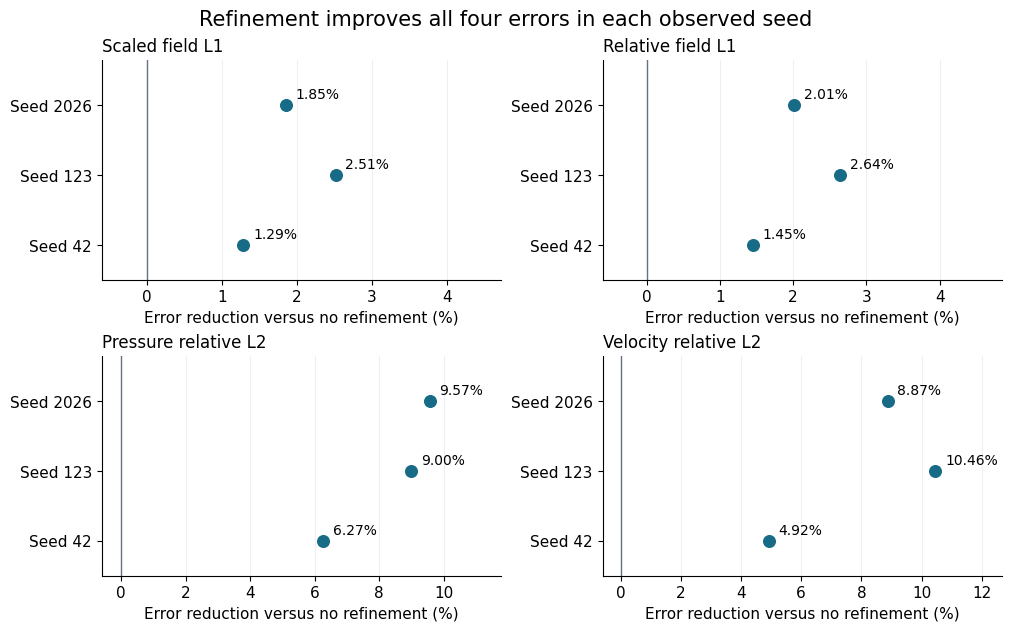

In [4]:
fig = stage.plot_seed_effects(runs)
fig.savefig(REPORT_ROOT / "refinement_seed_effects.png", dpi=180)
plt.show()
plt.close(fig)


## Stage 2. Regional errors and paired uncertainty

The headline table averages cases within each run and then seeds. The intervals below use a distinct, explicitly labeled estimand: average conditions within each airfoil, then give each airfoil and seed equal weight. Therefore their central values can differ from the headline table.

The bootstrap resamples the matched seed and airfoil axes. With only three seeds and a repeatedly inspected development split, these are **exploratory intervals**, not a confirmatory significance or novelty test. Several comparisons and metrics are shown without multiplicity correction. Cases are not treated as independent training runs.

Inspect near-surface and wake errors, tail errors, and adverse cases together with global averages. Undefined values block the affected interval rather than being silently discarded. The regional summary reports the number of valid cases alongside each statistic.


,reference,candidate,metric,status,reduction_percent,absolute_ci_low,absolute_ci_high,valid_pairs
0,no_local_refinement,proposed,legacy_l1,ok,1.817127,0.000023,0.000112,1200
1,no_local_refinement,proposed,legacy_rel_l1_aggregate,ok,1.977609,0.000150,0.000585,1200
2,no_local_refinement,proposed,p_rel_l2,ok,8.348942,0.007816,0.012686,1200
3,no_local_refinement,proposed,velocity_rel_l2,ok,8.119304,0.001603,0.003489,1200
4,no_local_refinement,proposed,near_velocity_rel_l2,ok,13.056075,0.010257,0.019386,1200
5,no_local_refinement,proposed,wake_velocity_rel_l2,ok,-0.384521,-0.001006,0.000548,1200
6,no_local_refinement,proposed,near_pressure_mae,ok,4.667414,0.001041,0.002080,1200
7,no_local_refinement,proposed,gradient_mae_to_target,ok,5.871310,0.007088,0.011518,1200
8,no_local_refinement,proposed,divergence_mae_to_target,ok,9.018428,0.005502,0.007322,1200
9,no_alignment,proposed,legacy_l1,ok,-0.024907,-0.000026,0.000026,1200


,variant,seed,metric,mean,median,p95,valid_cases,total_cases
4,no_alignment,42,near_velocity_rel_l2,0.104999,0.084436,0.258304,400,400
5,no_alignment,42,wake_velocity_rel_l2,0.056935,0.034320,0.194118,400,400
6,no_alignment,42,near_pressure_mae,0.031003,0.019520,0.094128,400,400
7,no_alignment,42,gradient_mae_to_target,0.145747,0.099240,0.381008,400,400
8,no_alignment,42,divergence_mae_to_target,0.062160,0.050889,0.131965,400,400
13,no_alignment,123,near_velocity_rel_l2,0.102537,0.081314,0.244197,400,400
14,no_alignment,123,wake_velocity_rel_l2,0.063256,0.039204,0.215775,400,400
15,no_alignment,123,near_pressure_mae,0.031652,0.018583,0.097267,400,400
16,no_alignment,123,gradient_mae_to_target,0.156547,0.104040,0.415138,400,400
17,no_alignment,123,divergence_mae_to_target,0.066146,0.052313,0.143065,400,400


,selection,sample_id,airfoil_id,legacy_rel_l1_aggregate
200,median backbone error,naca643418_6676_702,naca643418,0.010850
379,95th percentile backbone error,stf86361_4685_1462,stf86361,0.050896
399,worst backbone error,sc21006_8319_3274,sc21006,0.198879


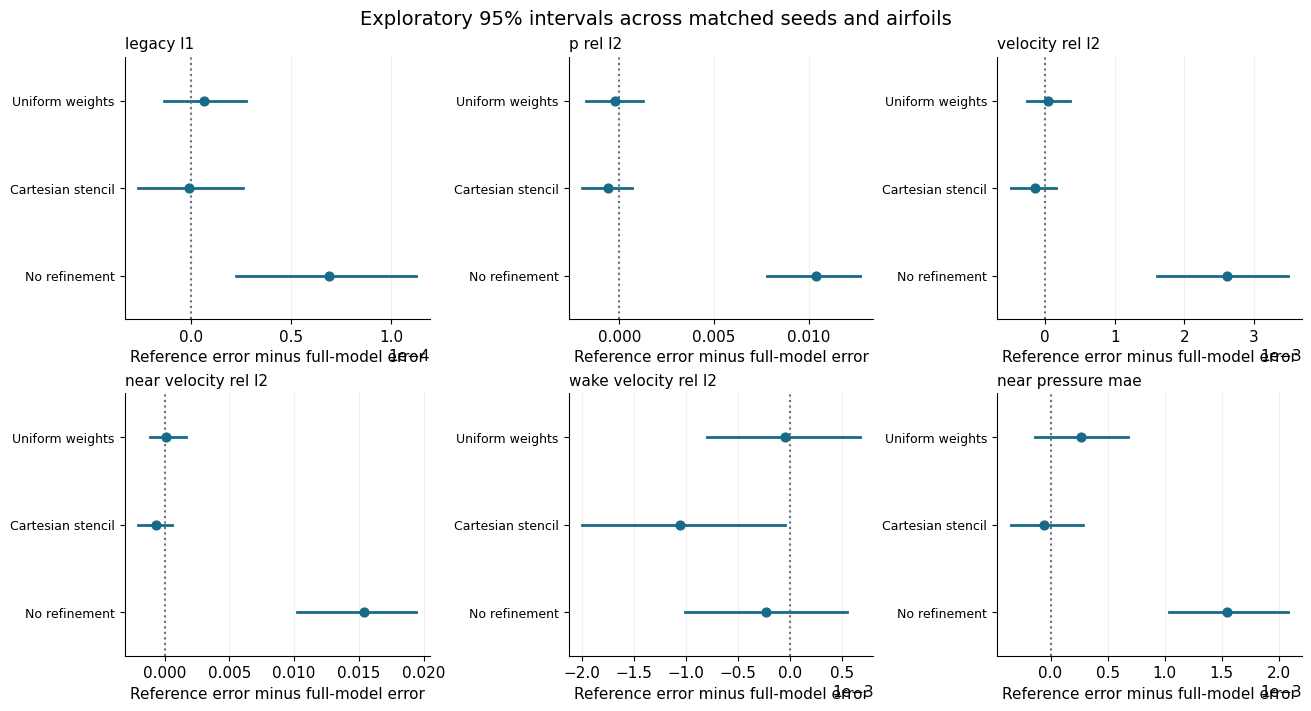

In [5]:
intervals = regional = selected_cases = None
if audit is not None:
    intervals, regional = stage.regional_analysis(cases, repetitions=BOOTSTRAP_REPETITIONS)
    selected_cases = stage.selected_validation_cases(cases)
    stage.write_csv(REPORT_ROOT / "paired_validation_intervals.csv", intervals)
    stage.write_csv(REPORT_ROOT / "regional_case_summaries.csv", regional)
    stage.write_csv(REPORT_ROOT / "selected_validation_cases.csv", selected_cases)
    display(intervals[["reference", "candidate", "metric", "status", "reduction_percent",
                       "absolute_ci_low", "absolute_ci_high", "valid_pairs"]].round(6))
    display(regional[regional.metric.isin(stage.REGIONAL_METRICS)].round(6))
    display(selected_cases)
    figure = stage.plot_intervals(intervals)
    figure.savefig(REPORT_ROOT / "paired_validation_intervals.png", dpi=180)
    plt.show()
    plt.close(figure)
else:
    print("Case-level validation CSVs are required. No regional results or confidence intervals are inferred from aggregate rows.")


### Decision after the analysis

| Evidence | Research decision |
|---|---|
| Refinement improves global and relevant regional errors across seeds | Retain refinement as a candidate contribution. |
| Alignment and learned weights stay mixed | Treat them as investigated options, without claiming demonstrated gains. `no_alignment` remains a candidate. |
| Global gains hide near-surface or wake degradation | Report the failure and investigate it before final model selection. |
| A conventional CNN refiner matches the proposed stencil refiner | Narrow the claim to the benefit of refinement; the directional stencil is not established as necessary. |
| The proposed or simplified candidate wins against equally trained baselines | Proceed to a frozen, independent test protocol after development decisions are complete. |

Do not assume that removing alignment and adaptive weighting together will preserve performance. That joint configuration has not been tested.

**Immediate handoff:** the main files to review next are `audited_runs.csv`, `paired_validation_intervals.csv`, `regional_case_summaries.csv`, and `selected_validation_cases.csv` in this session's report directory. No additional training is needed to create them.


## Stage 3. Optional validation figures and inference costs

In the first settings cell, set `RUN_VALIDATION_FIGURES = True` and/or `RUN_INFERENCE_TIMING = True`, select a GPU runtime, then rerun setup, the audit, and this stage. The three illustrated cases are chosen by the no-refinement model's median, 95th-percentile, and worst aggregate validation errors for seed 42. All four variants use the same cases and shared field/error color scales. This case selection is a diagnostic, not a representative test sample.

Pressure is centered independently by each field's own fluid mean. Inference measurements use batch sizes 1 and 10, 5 warmup passes, and 30 measured passes on the same GPU. They measure resident-tensor FP32 forward passes, excluding preprocessing and transfers. Incremental memory is measured separately from parameter memory. Existing training-time plots are not inference benchmarks.

Only your locally generated, trusted checkpoints are loaded. A changed core fingerprint or selected checkpoint identity stops this stage.


In [6]:
core = None
if MODE == "drive" and (RUN_VALIDATION_FIGURES or RUN_INFERENCE_TIMING):
    core = stage.load_core(CORE_PATH, audit["core_fingerprint"])
    inference_results = stage.validation_diagnostics(core, audit, PREPARED_ROOT, STUDY_ROOT, REPORT_ROOT,
        make_figures=RUN_VALIDATION_FIGURES, measure_inference=RUN_INFERENCE_TIMING)
    if not inference_results.empty:
        display(inference_results)
else:
    print("Optional checkpoint figures and inference timing are disabled.")


Optional checkpoint figures and inference timing are disabled.


## Stage 4. Prepare the next experiment plan

First complete the inexpensive analysis above. The next training matrix keeps 10,000 total steps, validation every 500 steps, seeds **42, 123, 2026**, the same data split, supervised L1, FP32, and the original optimizer settings. The completed ablations are reused as comparison results.

| New configuration | Runs | Purpose |
|---|---:|---|
| `dfp_original` | 3 | Compare against the original architecture at the same budget. |
| `modern_unet` | 3 | Compare against a conventional residual U-Net. |
| `fno` | 3 | Compare against a conventional Fourier neural operator. |
| `conv_refiner_control`, optional | 3 | Distinguish stencil refinement from ordinary CNN refinement. |

The CNN control retains the same backbone, conditioning, two shared refinement iterations, and zero-initialized output correction. It replaces sampled directional differences and adaptive gates with a learned 1×1 projection and an ordinary 3×3 residual mixing block. At base width 32 it has **360 fewer parameters** than the full model, approximately 0.0063%. It is a comparable-capacity control, not an exact parameter match.

This stage writes the new plan but performs no optimizer steps. Both the original core fingerprint and the new runner's source hash are recorded. Do not change these settings inside an existing new-study directory.

The original notebook's default full benchmark uses 80,000 steps and a different default second seed, 137. This workflow explicitly uses the completed study's 10,000-step budget and seed 123. Moving later to a larger budget requires a new study and freshly defined learning-rate schedules; do not relabel or silently extend these runs.


In [7]:
plan = None
if MODE == "drive":
    if core is None:
        core = stage.load_core(CORE_PATH, audit["core_fingerprint"])
    plan = stage.prepare_plan(core, audit, CORE_PATH, NEXT_ROOT)
    planned_rows = []
    for name, config in plan["configs"].items():
        candidate = stage.build_model(core, config)
        planned_rows.append({"experiment": name, "seeds": plan["seeds"],
            "steps_per_seed": config["max_steps"], "validation_every": config["validation_every"],
            **core.model_size(candidate)})
        del candidate
    display(pd.DataFrame(planned_rows))
    display(stage.progress_table(NEXT_ROOT, plan))
    print("New plan prepared. Training is controlled by RUN_NEXT_CHUNK.")
else:
    print("The live helper and audited run identities are required to register the next experiment plan.")


,experiment,seeds,steps_per_seed,validation_every,real_scalar_parameters,parameter_bytes
0,dfp_original,"[42, 123, 2026]",10000,500,7736067,30944268
1,modern_unet,"[42, 123, 2026]",10000,500,2061923,8247692
2,fno,"[42, 123, 2026]",10000,500,5323251,21293004
3,conv_refiner_control,"[42, 123, 2026]",10000,500,5690198,22760792


,experiment,variant,seed,saved_step,target,status
0,dfp_original_seed42,dfp_original,42,0,10000,waiting
1,modern_unet_seed42,modern_unet,42,0,10000,waiting
2,fno_seed42,fno,42,0,10000,waiting
3,conv_refiner_control_seed42,conv_refiner_control,42,0,10000,waiting
4,dfp_original_seed123,dfp_original,123,0,10000,waiting
5,modern_unet_seed123,modern_unet,123,0,10000,waiting
6,fno_seed123,fno,123,0,10000,waiting
7,conv_refiner_control_seed123,conv_refiner_control,123,0,10000,waiting
8,dfp_original_seed2026,dfp_original,2026,0,10000,waiting
9,modern_unet_seed2026,modern_unet,2026,0,10000,waiting


New plan prepared. Training is controlled by RUN_NEXT_CHUNK.


## Stage 5. Run one new training chunk when ready

Enable `RUN_NEXT_CHUNK = True` in the settings cell after reviewing the validation analysis. Keep `ACTIVE_EXPERIMENTS = ["dfp_original", "modern_unet", "fno"]` for the baseline comparison. For the optional mechanism control, use `["conv_refiner_control"]` instead.

Each execution below advances only the first unfinished experiment in the active queue by at most `CHUNK_STEPS`. Rerun this cell for another chunk. After a disconnect, rerun setup and the earlier cells to restore the state, then continue. Use `CHUNK_STEPS = 500` for shorter sessions. It must remain a multiple of 500.

The soft time limit is checked only after a validation checkpoint, so one validation interval and I/O can overrun it. GPU allocation limits still depend on Colab. Checkpoints save model, optimizer, random-number state, selected best step, and history. A partial chunk never receives a completion marker. A complete run is marked only after its actual saved step reaches 10,000 and the selected validation predictions have been regenerated.

This code has been statically checked and its pure checkpoint-recovery logic has been tested locally. Full GPU training/resume equivalence could not be executed here because PyTorch, the CFD arrays, and your checkpoints were unavailable. Start with one 500-step chunk, confirm its progress, then resume it before processing the remaining queue. CUDA grid-sampling backward may remain nondeterministic.


In [8]:
if MODE == "drive" and RUN_NEXT_CHUNK:
    progress = stage.run_next_chunk(core, PREPARED_ROOT, audit["split"], NEXT_ROOT, plan,
        ACTIVE_EXPERIMENTS, chunk_steps=CHUNK_STEPS, session_minutes=SESSION_MINUTES)
    display(progress)
elif MODE == "drive":
    print("Training disabled. Review the analysis, then enable RUN_NEXT_CHUNK when ready.")
else:
    print("No training runs in snapshot mode.")


Training disabled. Review the analysis, then enable RUN_NEXT_CHUNK when ready.


## Stage 6. Compare completed new experiments

Only configurations with all three completed seeds enter the following comparison. The audit verifies their full case coverage before joining them with the existing ablations. The missing configurations remain listed in the progress table. This makes the denominators explicit while allowing completed comparisons to be examined.

The primary research target remains a fair comparison to DFP, supported by U-Net and FNO comparisons and component controls. Report all planned results, including adverse regional effects. Comparing these 10,000-step models with the earlier 2,000-step screen is not evidence of an architecture advantage.


In [9]:
if MODE == "drive" and plan is not None:
    next_progress = stage.progress_table(NEXT_ROOT, plan)
    complete_names = [name for name in plan["configs"]
        if (next_progress[next_progress.variant == name].status == "completed").all()]
    display(next_progress)
    if complete_names:
        new_audit = stage.audit_study(PREPARED_ROOT, SPLIT_PATH, NEXT_ROOT,
            names=complete_names, seeds=plan["seeds"], expected_configs=plan["configs"])
        combined = pd.concat([audit["cases"], new_audit["cases"]], ignore_index=True)
        combined_runs = pd.concat([audit["runs"], new_audit["runs"]], ignore_index=True)
        comparisons = [(name, candidate) for name in complete_names for candidate in ["proposed", "no_alignment"]]
        comparison_intervals, comparison_regions = stage.regional_analysis(combined, comparisons, BOOTSTRAP_REPETITIONS)
        stage.write_csv(REPORT_ROOT / "matched_budget_completed_runs.csv", combined_runs)
        stage.write_csv(REPORT_ROOT / "matched_budget_intervals.csv", comparison_intervals)
        stage.write_csv(REPORT_ROOT / "matched_budget_regional_summary.csv", comparison_regions)
        display(combined_runs[["variant", "seed", "steps", "validation_L1", "validation_pressure_L2", "validation_velocity_L2"]].round(6))
        display(comparison_intervals[comparison_intervals.metric.isin(stage.METRICS.values())].round(6))
        if RUN_INFERENCE_TIMING:
            baseline_timing_dir = REPORT_ROOT / "new_model_inference"
            baseline_timing_dir.mkdir(exist_ok=True)
            new_timings = stage.validation_diagnostics(core, new_audit, PREPARED_ROOT, NEXT_ROOT,
                baseline_timing_dir, make_figures=False, measure_inference=True,
                names=complete_names, reference_cases=audit["cases"])
            display(new_timings)
    else:
        print("No new configuration has three completed seeds yet. Existing results remain available.")
else:
    print("Matched-budget results will be generated only after real new runs complete.")


,experiment,variant,seed,saved_step,target,status
0,dfp_original_seed42,dfp_original,42,0,10000,waiting
1,modern_unet_seed42,modern_unet,42,0,10000,waiting
2,fno_seed42,fno,42,0,10000,waiting
3,conv_refiner_control_seed42,conv_refiner_control,42,0,10000,waiting
4,dfp_original_seed123,dfp_original,123,0,10000,waiting
5,modern_unet_seed123,modern_unet,123,0,10000,waiting
6,fno_seed123,fno,123,0,10000,waiting
7,conv_refiner_control_seed123,conv_refiner_control,123,0,10000,waiting
8,dfp_original_seed2026,dfp_original,2026,0,10000,waiting
9,modern_unet_seed2026,modern_unet,2026,0,10000,waiting


No new configuration has three completed seeds yet. Existing results remain available.


## Final research decisions and test handoff

1. Use the completed global, regional, visual, and compute comparisons to choose the architecture. Three seeds remain a limited estimate of training variability. Near-ties should be reported as such.
2. If the CNN control performs similarly, narrow the claimed mechanism. If stencil refinement produces a consistent, useful additional gain, document where it helps and its runtime cost.
3. Before claiming unseen-geometry generalization, use a grouped geometry holdout during development or the independent official test after finalization. The current random validation split can include different conditions of training airfoils.
4. Freeze the exact final architecture, baselines, budget, seeds, checkpoint-selection rule, primary metric, and test comparisons. Retain the recorded failed or inconclusive ablations. Do not select a winner using the official test set.
5. Run the official test in a separate final-evaluation workflow. The original benchmark function assumes the standard proposed model and its own run identities. If the selected model, budget, or runner differs, adapt that protocol explicitly rather than pointing it at incompatible new checkpoints.

**Publication framing supported now:** local refinement improves validation prediction within this hybrid geometry-conditioned architecture. Novelty, superiority to equally trained alternatives, independent test generalization, and a benefit specific to directional adaptive stencils remain questions to establish.

**Reproducibility sources:** the supplied V2 notebook and exact completed-run CSV are the sources for model interfaces, metrics, and experiment settings. Checkpoint handling follows [PyTorch's saving and loading guidance](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html). Reproducibility limits are described in [PyTorch's reproducibility notes](https://pytorch.org/docs/stable/notes/randomness.html). The runner also preserves the existing step-indexed sampler and learning-rate function.


In [10]:
report_note = {
    "mode": MODE, "workflow_version": stage.VERSION,
    "validation_status": "live records audited" if audit is not None else "aggregate snapshot only",
    "regional_analysis_performed": intervals is not None,
    "official_test_evaluated": False,
    "training_enabled": RUN_NEXT_CHUNK,
    "helper_sha256": helper_digest,
}
stage.write_json(REPORT_ROOT / "review_scope.json", report_note)
if MODE == "drive":
    print("Review outputs:", REPORT_ROOT)
else:
    print("Snapshot computations complete. Live project checks, GPU diagnostics, and new training remain pending.")


Review outputs: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/analysis/study03_review/20260917T142908822492Z
